# Effects in the invariant cores

Tests "the same effects" measured on the full scales in the two stepwise invariant-core sets:

- **triple** — the 3-way (validation / genpop / enriched) stepwise cores from `data/cfa/stepwise_scalar.pkl` (stepwise only, per author decision; exhaustive refinements not used). 10 scales have cores (3 scalar-level, 7 metric-level); appetite_loss, cognitive_problems, indecisiveness, and shame_guilt have none.
- **gp_en** — the GP↔EN stepwise cores from `data/cfa_gp_en/stepwise_scalar.pkl` (all 14 HiTOP scales, scalar level) plus the other-scale cores from `data/cfa_other_gp_en/stepwise_scalar.pkl` (PHQ **stepwise metric-fallback** core {phq_1,3,4,6,7} per author decision; the exhaustive 5-item scalar core is exploratory only).

Sections: (A) core inventory; (B) the effect-size suite (residual DIF bias with 95% CIs, dimensionality/ωH, power cost) on the cores, compared against the full-scale results from `NB_invariance_effect_sizes.ipynb`; (C) the preregistered convergent (C1–C7) and divergent (D1–D5) validity hypotheses computed with core sums, once per core set, via `hitop_cfa.convdiv` (faithful extraction of `NB_4_convdiv.ipynb`).

Outputs → `data/core_effects/`; figures → `figures/` (repo root).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from hitop_cfa import dif_effect_sizes, dimensionality_effect_sizes
from hitop_cfa.scales import ORIG_ITEMS, OTHER_SCALES
from hitop_cfa.lookup import load_item_lookup

pd.set_option('display.width', 250)
dat_dir = Path('../data')
fin_dir = dat_dir / 'finaldata'
out_dir = dat_dir / 'core_effects'
out_dir.mkdir(exist_ok=True)
fig_dir = Path('../figures')
fig_dir.mkdir(exist_ok=True)
temp_path = out_dir / 'ce_temp.csv'
FORMULAS = {**ORIG_ITEMS, **OTHER_SCALES}
def full_items_of(scale):
    return FORMULAS[scale].split('=~', 1)[1].strip().split(' + ')

## A. Core inventory

One row per (core set, scale): the invariance level the core reached, the retained items, and what was removed. `n_full`/`n_core` show the reduction.

In [2]:
triple_sw = pd.read_pickle(dat_dir / 'cfa' / 'stepwise_scalar.pkl')
gp_en_sw = pd.read_pickle(dat_dir / 'cfa_gp_en' / 'stepwise_scalar.pkl')
gp_en_other_sw = pd.read_pickle(dat_dir / 'cfa_other_gp_en' / 'stepwise_scalar.pkl')

inventory = []
def add_inventory(sw, core_set):
    for r in sw.itertuples():
        has_core = isinstance(r.core_level, str)
        items = list(r.item_nos) if has_core else []
        removed = list(r.removed_nos) if has_core else []
        inventory.append(dict(
            core_set=core_set, scale=r.scale,
            core_level=r.core_level if has_core else 'none',
            n_full=len(full_items_of(r.scale)), n_core=len(items),
            items=' '.join(items), removed=' '.join(removed)))

add_inventory(triple_sw, 'triple')
add_inventory(gp_en_sw, 'gp_en')
add_inventory(gp_en_other_sw, 'gp_en_other')
inventory = pd.DataFrame(inventory)
inventory.to_csv(out_dir / 'core_inventory.csv', index=False)
inventory

,core_set,scale,core_level,n_full,n_core,items,removed
0,triple,anhedonic_depression,metric,10,6,hitop77 hitop84 hitop92 hitop123 hitop182 hito...,hitop39 hitop93 hitop157 hitop246
1,triple,anxious_worry,metric,7,3,hitop240 hitop248 hitop265,hitop20 hitop34 hitop89 hitop203
2,triple,appetite_gain,metric,4,3,hitop141 hitop243 hitop275,hitop120
3,triple,appetite_loss,none,3,0,,
4,triple,cognitive_problems,none,4,0,,
5,triple,hyposomnia,metric,5,4,hitop99 hitop5 hitop66 hitop231,hitop181
6,triple,indecisiveness,none,3,0,,
7,triple,insomnia,scalar,4,3,hitop160 hitop254 hitop268,hitop261
8,triple,panic,scalar,6,3,hitop104 hitop126 hitop215,hitop15 hitop211 hitop257
9,triple,separation_insecurity,scalar,8,6,hitop40 hitop69 hitop81 hitop136 hitop151 hito...,hitop50 hitop113


## B. Effect-size suite on the cores

### B1. Residual DIF effect sizes

`dif_effect_sizes` (metric model, GLS-projected latent gap, simulated 95% CIs) on every core: triple cores on all three sample pairs (val_gp, val_en, gp_en; grid1st frames, pipeline concat orders), gp_en cores on gp_en only. For scalar-invariant cores these quantify the (statistically undetectable) residual DIF left after item removal; for metric-level cores they quantify the scalar-level DIF the core still carries.

In [3]:
data_val = pd.read_csv(fin_dir / 'dat_val.csv')
data_gp = pd.read_csv(fin_dir / 'dat_gp_grid1st_full.csv')
data_en = pd.read_csv(fin_dir / 'dat_en_grid1st_full.csv')
PAIR_DATA = {
    'val_gp': pd.concat([data_val, data_gp]),
    'val_en': pd.concat([data_val, data_en]),
    'gp_en': pd.concat([data_gp, data_en]),
}

runs = []
for r in triple_sw.itertuples():
    if isinstance(r.core_level, str):
        for pair in ('val_gp', 'val_en', 'gp_en'):
            runs.append(('triple', r.scale, list(r.item_nos),
                         r.core_level, pair))
for sw, set_name in ((gp_en_sw, 'gp_en'), (gp_en_other_sw, 'gp_en_other')):
    for r in sw.itertuples():
        if isinstance(r.core_level, str):
            runs.append((set_name, r.scale, list(r.item_nos),
                         r.core_level, 'gp_en'))
print(f'{len(runs)} core x pair DIF runs')

50 core x pair DIF runs


In [4]:
per_item_all, summary_all = [], []
for core_set, scale, items, core_level, pair in runs:
    print(f'--- [{core_set}] {scale} x {pair} ({core_level} core, '
          f'{len(items)} items) ---', flush=True)
    base = dict(core_set=core_set, scale=scale, pair=pair,
                core_level=core_level, n_core_items=len(items))
    try:
        per_item, s = dif_effect_sizes(scale, items, PAIR_DATA[pair],
                                       temp_path)
    except Exception as exc:
        print(f'    ERROR: {exc!r}')
        summary_all.append(dict(**base, error=repr(exc)))
        continue
    if per_item is None:
        print('    metric model did not converge')
        summary_all.append(dict(**base, error='nonconverged'))
        continue
    for k, v in [('pair', pair), ('scale', scale), ('core_set', core_set)]:
        per_item.insert(0, k, v)
    per_item_all.append(per_item)
    summary_all.append(dict(
        **base, scale_max=s['scale_max_points'],
        alpha=round(s['alpha'], 3),
        alpha_lo=round(s['alpha_ci'][0], 3),
        alpha_hi=round(s['alpha_ci'][1], 3),
        real_gap_pts=round(s['real_gap_points'], 2),
        net_bias_pts=round(s['net_sum_bias_points'], 2),
        net_lo=round(s['net_ci'][0], 2), net_hi=round(s['net_ci'][1], 2),
        gross_bias_pts=round(s['gross_abs_bias_points'], 2),
        gross_lo=round(s['gross_ci'][0], 2),
        gross_hi=round(s['gross_ci'][1], 2),
        max_dMACS=round(per_item.dMACS.max(), 3),
        max_dMACS_item=per_item.loc[per_item.dMACS.idxmax(), 'item'],
        error=None))

per_item_cores = pd.concat(per_item_all, ignore_index=True)
core_summary = pd.DataFrame(summary_all)
per_item_cores.to_csv(out_dir / 'dif_cores_per_item.csv', index=False)
core_summary.to_csv(out_dir / 'dif_cores_summary.csv', index=False)
print(f'saved {len(per_item_cores)} item rows / {len(core_summary)} '
      f'core x pair summaries')

--- [triple] anhedonic_depression x val_gp (metric core, 6 items) ---


--- [triple] anhedonic_depression x val_en (metric core, 6 items) ---


--- [triple] anhedonic_depression x gp_en (metric core, 6 items) ---


--- [triple] anxious_worry x val_gp (metric core, 3 items) ---


--- [triple] anxious_worry x val_en (metric core, 3 items) ---


...

--- [gp_en_other] baars_inattention_sum x gp_en (scalar core, 6 items) ---


--- [gp_en_other] baars_hyperactivity_sum x gp_en (scalar core, 5 items) ---


--- [gp_en_other] baars_impulsivity_sum x gp_en (scalar core, 4 items) ---


--- [gp_en_other] baars_sct_sum x gp_en (scalar core, 6 items) ---


saved 218 item rows / 50 core x pair summaries


In [5]:
ok = core_summary[core_summary.error.isna()].copy()
ok['net_pct'] = (ok.net_bias_pts / ok.scale_max * 100).round(1)
ok['gross_pct'] = (ok.gross_bias_pts / ok.scale_max * 100).round(1)
cols = ['core_set', 'scale', 'pair', 'core_level', 'n_core_items', 'alpha',
        'real_gap_pts', 'net_bias_pts', 'net_lo', 'net_hi', 'net_pct',
        'gross_bias_pts', 'gross_pct', 'max_dMACS', 'max_dMACS_item']
sig_net = ok[(ok.net_lo > 0) | (ok.net_hi < 0)]
print(f'{len(sig_net)} of {len(ok)} core x pair net-bias CIs exclude zero')
sig_items = per_item_cores[(per_item_cores.d_lo > 0)
                           | (per_item_cores.d_hi < 0)]
print(f'{len(sig_items)} of {len(per_item_cores)} item-level DIF CIs '
      f'exclude zero')
ok.sort_values('gross_pct', ascending=False)[cols]

1 of 50 core x pair net-bias CIs exclude zero
46 of 218 item-level DIF CIs exclude zero


,core_set,scale,pair,core_level,n_core_items,alpha,real_gap_pts,net_bias_pts,net_lo,net_hi,net_pct,gross_bias_pts,gross_pct,max_dMACS,max_dMACS_item
10,triple,hyposomnia,val_en,metric,4,-0.395,-0.34,-0.21,-0.57,0.21,-1.7,0.65,5.4,0.390,hitop5
23,triple,situational_phobia,gp_en,metric,5,0.501,1.23,-0.01,-0.27,0.55,-0.1,0.77,5.1,0.286,hitop225
3,triple,anxious_worry,val_gp,metric,3,-0.993,-2.24,-0.12,-0.27,0.01,-1.3,0.43,4.8,0.241,hitop265
44,gp_en_other,phq_sum,gp_en,metric,5,1.134,4.80,0.14,-0.03,0.41,0.9,0.68,4.5,0.223,phq_7
4,triple,anxious_worry,val_en,metric,3,0.240,0.64,0.06,-0.21,0.40,0.7,0.39,4.3,0.194,hitop248
2,triple,anhedonic_depression,gp_en,metric,6,1.101,5.32,0.07,-0.09,0.42,0.4,0.73,4.1,0.192,hitop123
26,triple,social_anxiety,gp_en,metric,6,0.970,4.82,0.05,-0.16,0.49,0.3,0.71,3.9,0.185,hitop129
25,triple,social_anxiety,val_en,metric,6,0.267,1.28,-0.13,-0.49,0.29,-0.7,0.64,3.6,0.173,hitop124
1,triple,anhedonic_depression,val_en,metric,6,0.369,1.50,0.15,-0.09,0.49,0.8,0.64,3.6,0.176,hitop123
22,triple,situational_phobia,val_en,metric,5,-0.276,-0.14,-0.12,-0.35,0.21,-0.8,0.52,3.5,0.203,hitop225


### B2. Full scale vs core

Join against the full-scale results (`data/effect_sizes/pairwise_dif_summary.csv`, generated in `NB_invariance_effect_sizes.ipynb`). Full-scale rows exist only where the full scale violated invariance for that pair, so pairs the full scale already passed have no comparison row. The dumbbell figure shows gross |bias| (% of scale range): gray = full scale, colored = core.

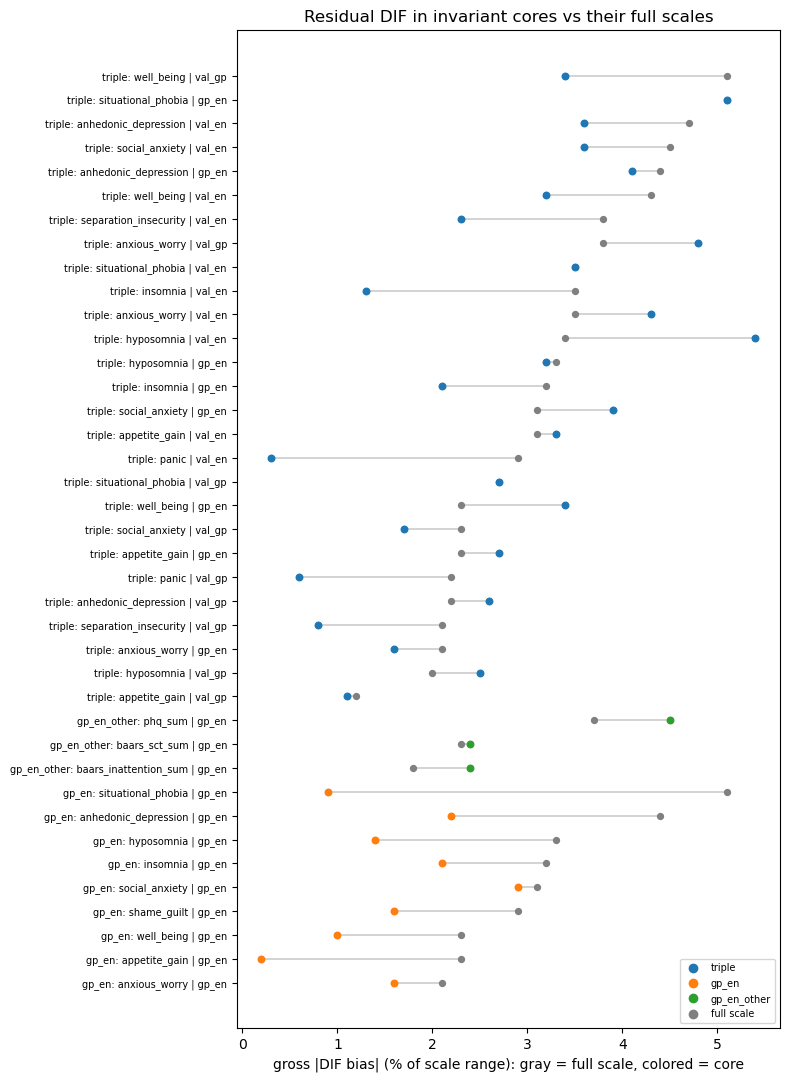

mean gross-bias reduction (percentage points of scale range): 0.58; worsened rows: 12


In [6]:
full = pd.read_csv(dat_dir / 'effect_sizes' / 'pairwise_dif_summary.csv')
full = full[full.error.isna()].copy()
full['gross_pct'] = (full.gross_bias_pts / full.scale_max * 100).round(1)
full['net_pct'] = (full.net_bias_pts / full.scale_max * 100).round(1)
comp = ok.merge(full[['scale', 'pair', 'failed_at', 'net_pct', 'gross_pct',
                      'max_dMACS']],
                on=['scale', 'pair'], how='left',
                suffixes=('_core', '_full'))
comp.to_csv(out_dir / 'dif_full_vs_core.csv', index=False)
have = comp[comp.gross_pct_full.notna()].copy()
have['label'] = have.core_set + ': ' + have.scale + ' | ' + have.pair
have = have.sort_values(['core_set', 'gross_pct_full'])
fig, ax = plt.subplots(figsize=(8, max(4, 0.28 * len(have))))
y = np.arange(len(have))
set_colors = {'triple': 'tab:blue', 'gp_en': 'tab:orange',
              'gp_en_other': 'tab:green'}
for j, r in enumerate(have.itertuples()):
    ax.plot([r.gross_pct_full, r.gross_pct_core], [j, j],
            color='lightgray', lw=1.4, zorder=1)
    ax.scatter(r.gross_pct_full, j, color='gray', s=18, zorder=2)
    ax.scatter(r.gross_pct_core, j, color=set_colors[r.core_set], s=22,
               zorder=3)
ax.set_yticks(y)
ax.set_yticklabels(have.label, fontsize=7)
ax.set_xlabel('gross |DIF bias| (% of scale range): gray = full scale, '
              'colored = core')
ax.set_title('Residual DIF in invariant cores vs their full scales')
handles = [plt.Line2D([], [], marker='o', ls='', color=c, label=s)
           for s, c in set_colors.items() if s in set(have.core_set)]
handles.append(plt.Line2D([], [], marker='o', ls='', color='gray',
                          label='full scale'))
ax.legend(handles=handles, fontsize=7, loc='lower right')
fig.tight_layout()
fig.savefig(fig_dir / 'core_vs_full_dif.png', dpi=150, bbox_inches='tight')
plt.show()
red = have.assign(delta=have.gross_pct_full - have.gross_pct_core)
print('mean gross-bias reduction (percentage points of scale range): '
      f'{red.delta.mean():.2f}; worsened rows: {(red.delta < 0).sum()}')

### B3. Dimensionality and power cost of the cores

`dimensionality_effect_sizes` (2-factor geomin → exact Schmid–Leiman → φ, ECV, ωH, attenuation √ωH, required-n inflation 1/ωH) per core × group. The 2-factor EFA needs ≥5 items, so 3–4-item cores are skipped (reported as `not identified`); that is expected, not missing data. Power table: required n for 80% power (two-sided α=.05) at r_true = .10/.15/.20 via the same Fisher-z machinery as `NB_invariance_effect_sizes.ipynb`.

In [7]:
GROUPS = {
    'triple': [('validation', data_val), ('genpop', data_gp),
               ('enriched', data_en)],
    'gp_en': [('genpop', data_gp), ('enriched', data_en)],
    'gp_en_other': [('genpop', data_gp), ('enriched', data_en)],
}
seen = set()
dim_rows = []
for core_set, scale, items, core_level, _pair in runs:
    key = (core_set, scale)
    if key in seen:
        continue
    seen.add(key)
    for label, frame in GROUPS[core_set]:
        print(f'--- [{core_set}] {scale} | {label} ---', flush=True)
        try:
            r = dimensionality_effect_sizes(scale, items, frame,
                                            out_dir / 'dim_temp.csv',
                                            verbose=True)
        except Exception as exc:
            print(f'   ERROR: {exc!r}')
            r = dict(converged=False, reason=repr(exc))
        row = dict(core_set=core_set, scale=scale, group=label,
                   core_level=core_level, n_core_items=len(items))
        row.update({k: (round(x, 3) if isinstance(x, float) else x)
                    for k, x in r.items()})
        dim_rows.append(row)
dim_cores = pd.DataFrame(dim_rows)
dim_cores.to_csv(out_dir / 'dimensionality_cores.csv', index=False)
print(f'saved {len(dim_cores)} core x group rows')

--- [triple] anhedonic_depression | validation ---


--- [triple] anhedonic_depression | genpop ---


  phi = 0.887 [0.675, 1.099]  ECV = 0.908  omegaH = 0.876  omegaT = 0.933
  criterion-correlation attenuation = 0.936  required-n inflation = 1.14x
  corr(sum, F1) = 0.930, corr(sum, F2) = 0.946
--- [triple] anhedonic_depression | enriched ---


  phi = 0.530 [0.283, 0.777]  ECV = 0.573  omegaH = 0.586  omegaT = 0.883
  criterion-correlation attenuation = 0.766  required-n inflation = 1.71x
  corr(sum, F1) = 0.712, corr(sum, F2) = 0.897
--- [triple] anxious_worry | validation ---


--- [triple] anxious_worry | genpop ---


...

--- [gp_en_other] baars_impulsivity_sum | genpop ---


--- [gp_en_other] baars_impulsivity_sum | enriched ---


--- [gp_en_other] baars_sct_sum | genpop ---


  phi = 0.720 [0.603, 0.837]  ECV = 0.776  omegaH = 0.768  omegaT = 0.918
  criterion-correlation attenuation = 0.876  required-n inflation = 1.30x
  corr(sum, F1) = 0.875, corr(sum, F2) = 0.901
--- [gp_en_other] baars_sct_sum | enriched ---


saved 70 core x group rows


In [8]:
from scipy.stats import norm

def n_for_power(r_obs, target=0.80, alpha=0.05):
    return int(np.ceil(((norm.ppf(1 - alpha / 2) + norm.ppf(target))
                        / np.arctanh(r_obs)) ** 2 + 3))

okd = dim_cores[dim_cores.converged == True].copy()
full_dim = pd.read_csv(dat_dir / 'effect_sizes'
                       / 'dimensionality_effect_sizes.csv')
full_dim = full_dim[full_dim.converged == True]
full_att = (full_dim.groupby(['scale', 'group'])['attenuation'].min()
            .rename('attenuation_fullscale'))
prow = []
for r in okd.itertuples():
    prow.append(dict(
        core_set=r.core_set, scale=r.scale, group=r.group,
        phi=r.phi, omega_h=r.omega_h, attenuation=r.attenuation,
        n80_r10=n_for_power(0.10 * r.attenuation),
        n80_r15=n_for_power(0.15 * r.attenuation),
        n80_r20=n_for_power(0.20 * r.attenuation)))
power_cores = pd.DataFrame(prow).join(
    full_att, on=['scale', 'group'])
power_cores.to_csv(out_dir / 'power_cores.csv', index=False)
print('ideal n80: r=.10: {}, r=.15: {}, r=.20: {}'.format(
    n_for_power(0.10), n_for_power(0.15), n_for_power(0.20)))
skipped = dim_cores[dim_cores.converged != True]
print(f"{len(skipped)} core x group rows without a 2-factor solution "
      f"(3-4-item cores are structurally excluded):")
print(skipped.groupby(['core_set', 'reason']).size().to_string())
power_cores.sort_values('attenuation')

ideal n80: r=.10: 783, r=.15: 347, r=.20: 194
46 core x group rows without a 2-factor solution (3-4-item cores are structurally excluded):
core_set     reason                       
gp_en        2-factor EFA did not converge     3
             2-factor EFA not identified      16
gp_en_other  2-factor EFA did not converge     3
             2-factor EFA not identified       2
triple       2-factor EFA did not converge     4
             2-factor EFA not identified      18


,core_set,scale,group,phi,omega_h,attenuation,n80_r10,n80_r15,n80_r20,attenuation_fullscale
10,gp_en,anxious_worry,genpop,0.101,0.103,0.321,7616,3384,1903,NaN
14,gp_en,separation_insecurity,enriched,0.489,0.537,0.733,1459,648,363,NaN
1,triple,anhedonic_depression,enriched,0.530,0.586,0.766,1336,593,333,NaN
9,gp_en,anhedonic_depression,enriched,0.619,0.658,0.811,1192,529,297,NaN
4,triple,situational_phobia,validation,0.651,0.666,0.816,1177,522,293,NaN
18,gp_en_other,phq_sum,enriched,0.647,0.682,0.826,1149,510,286,0.874
12,gp_en,panic,enriched,0.715,0.714,0.845,1098,487,273,NaN
20,gp_en_other,gad_sum,enriched,0.651,0.723,0.850,1085,481,270,NaN
7,triple,social_anxiety,enriched,0.710,0.745,0.863,1052,467,262,0.924
13,gp_en,separation_insecurity,genpop,0.701,0.756,0.869,1038,460,258,0.869


## C. Preregistered validity hypotheses with core sums

C1–C7 and D1–D5 (plus the exploratory exd4/exd5 and per-sample C7 rows carried over from `NB_4_convdiv.ipynb`), computed with `hitop_cfa.convdiv` — a faithful extraction of NB_4's code — once per core set. Per the prereg, HiTOP sums exclude well_being, and scales without an invariant core fall back to the full scale with a warning (NB_4's behavior; the prereg's stricter enriched-sample-only rule is a documented deviation).

Criterion measures: in the **triple** run the criteria (PHQ-8, GAD-7, BAARS) are full-scale sums (they were never tested for triple invariance). In the **gp_en** run the criteria also use their gp_en cores: `phq_sum` is rebuilt from the stepwise metric-fallback core and `baars_sum` uses the 6-item inattention core plus the (fully invariant) hyperactivity and impulsivity scales. GAD-7 and the single PHQ items (C4–C6) are unchanged.

In [9]:
from hitop_cfa import (ALL_HITOP_SCALES, ANX_SCALES, DEP_SCALES,
                       HITOP_SUM_SCALES, add_core_aliases,
                       add_core_sum_columns, check_convergent_hypotheses,
                       divergent_results_table, prepare_divergent_data,
                       resolve_cores, run_divergent)

seed = 12345

def cores_frame(stepwise):
    '''NB_4-format cores frame from a stepwise_scalar pickle: reduced cores
    named hitop_{scale}__invcore, full-scale cores keep the bare name.'''
    rows = []
    for r in stepwise.itertuples():
        if not isinstance(r.core_level, str):
            continue
        reduced = len(list(r.removed_nos)) > 0
        rows.append(dict(
            scale=f'hitop_{r.scale}__invcore' if reduced else r.scale,
            core_level=r.core_level, item_nos=list(r.item_nos),
            reduced=reduced))
    return pd.DataFrame(rows)

def fresh_data(criteria_cores=None):
    dgp = pd.read_csv(fin_dir / 'dat_gp_grid1st_full.csv').rename(
        columns={'Unnamed: 0': 'Subject'})
    den = pd.read_csv(fin_dir / 'dat_en_grid1st_full.csv').rename(
        columns={'Unnamed: 0': 'Subject'})
    frames = [dgp, den]
    if criteria_cores is not None:
        for f in frames:
            f['phq_sum'] = f[criteria_cores['phq']].sum(axis=1)
            f['baars_sum'] = f[criteria_cores['baars']].sum(axis=1)
        print(f"criterion overrides: phq_sum from "
              f"{criteria_cores['phq']}; baars_sum from "
              f"{len(criteria_cores['baars'])} items "
              f"(inattention core + full hyperactivity/impulsivity)")
    dcomb = pd.concat(frames)
    return dgp, den, dcomb

def run_validity(set_name, cores, criteria_cores=None):
    print(f'================ core set: {set_name} ================')
    dgp, den, dcomb = fresh_data(criteria_cores)
    core_resolution, res_df = resolve_cores(cores)
    print(res_df.to_string())
    res_df.to_csv(out_dir / f'core_resolution_{set_name}.csv')
    add_core_sum_columns([dgp, den, dcomb], cores)
    add_core_aliases([dgp, den, dcomb], core_resolution)
    hitop_sum_cols = [f'hitop_{s}__core' for s in HITOP_SUM_SCALES]
    dep_scales = [f'hitop_{s}__core' for s in DEP_SCALES]
    anx_scales = [f'hitop_{s}__core' for s in ANX_SCALES]
    dcomb = dcomb.copy()
    conv = check_convergent_hypotheses(dcomb, hitop_sum_cols)
    rng = np.random.default_rng(seed=seed)
    mydata = prepare_divergent_data(dcomb, hitop_sum_cols, dep_scales,
                                    anx_scales)
    from hitop_cfa.convdiv import COLS_FOR_D
    nmiss = mydata[COLS_FOR_D].isna().any(axis=1).sum()
    if nmiss:
        print(f'dropping {nmiss} rows with missing divergent-test columns '
              f'(prereg: prefer-not-to-answer exclusions)')
        mydata = mydata.dropna(subset=COLS_FOR_D).reset_index(drop=True)
    perm_res, bootdf, pvals = run_divergent(mydata, rng)
    div = divergent_results_table(perm_res, bootdf, pvals)
    div.insert(1, 'test_type', 'permutation_MI_or_spearman_diff')
    both = pd.concat([conv, div], ignore_index=True)
    both.insert(0, 'core_set', set_name)
    both.to_csv(out_dir / f'convdiv_{set_name}.csv', index=False)
    perm_res.to_pickle(out_dir / f'divergent_perm_res_{set_name}.pkl')
    bootdf.to_pickle(out_dir / f'divergent_boot_res_{set_name}.pkl')
    return both

In [10]:
triple_cores = cores_frame(triple_sw)
res_triple = run_validity('triple', triple_cores)

================ core set: triple ================

                                                     column               resolution core_level
anhedonic_depression    hitop_anhedonic_depression__invcore     confirmatory_reduced     metric
appetite_gain                  hitop_appetite_gain__invcore     confirmatory_reduced     metric
appetite_loss                           hitop_appetite_loss        no_invariant_core        NaN
cognitive_problems                 hitop_cognitive_problems        no_invariant_core        NaN
hyposomnia                        hitop_hyposomnia__invcore     confirmatory_reduced     metric
indecisiveness                         hitop_indecisiveness        no_invariant_core        NaN
insomnia                            hitop_insomnia__invcore     confirmatory_reduced     scalar
shame_guilt                               hitop_shame_guilt        no_invariant_core        NaN
anxious_worry                  hitop_anxious_worry__invcore     confirmatory_reduced

/Users/nielsond/code/hitop_val/scalar/src/hitop_cfa/convdiv.py:80: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[row.scale] = data.loc[:, tmp_items].sum(axis=1)
/Users/nielsond/code/hitop_val/scalar/src/hitop_cfa/convdiv.py:83: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[f'{row.scale}_recontact'] = (
/Users/nielsond/code/hitop_val/scalar/src/hitop_cfa/convdiv.py:80: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consid

d1:0.000999000999000999
d2:0.000999000999000999
d3:0.984015984015984
d4:0.5064935064935064
d5:0.15984015984015984
exd4:0.03996003996003996
exd5:0.006993006993006993


In [11]:
gp_en_cores = cores_frame(gp_en_sw)
phq_core = list(gp_en_other_sw.set_index('scale')
                .loc['phq_sum', 'item_nos'])
inatt_core = list(gp_en_other_sw.set_index('scale')
                  .loc['baars_inattention_sum', 'item_nos'])
baars_items = (inatt_core
               + full_items_of('baars_hyperactivity_sum')
               + full_items_of('baars_impulsivity_sum'))
res_gp_en = run_validity('gp_en', gp_en_cores,
                         criteria_cores=dict(phq=phq_core,
                                             baars=baars_items))

================ core set: gp_en ================
criterion overrides: phq_sum from ['phq_1', 'phq_3', 'phq_4', 'phq_6', 'phq_7']; baars_sum from 15 items (inattention core + full hyperactivity/impulsivity)
                                                    column               resolution core_level
anhedonic_depression   hitop_anhedonic_depression__invcore     confirmatory_reduced     scalar
appetite_gain                 hitop_appetite_gain__invcore     confirmatory_reduced     scalar
appetite_loss                          hitop_appetite_loss  confirmatory_full_scale     scalar
cognitive_problems                hitop_cognitive_problems  confirmatory_full_scale     scalar
hyposomnia                       hitop_hyposomnia__invcore     confirmatory_reduced     scalar
indecisiveness                        hitop_indecisiveness  confirmatory_full_scale     scalar
insomnia                           hitop_insomnia__invcore     confirmatory_reduced     scalar
shame_guilt                     h

/Users/nielsond/code/hitop_val/scalar/src/hitop_cfa/convdiv.py:80: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[row.scale] = data.loc[:, tmp_items].sum(axis=1)
/Users/nielsond/code/hitop_val/scalar/src/hitop_cfa/convdiv.py:83: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[f'{row.scale}_recontact'] = (
/Users/nielsond/code/hitop_val/scalar/src/hitop_cfa/convdiv.py:80: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consid

d1:0.000999000999000999
d2:0.000999000999000999
d3:1.0
d4:0.10989010989010989
d5:0.1798201798201798
exd4:0.14985014985014986
exd5:0.012987012987012988


### Comparison across core sets

Same hypotheses, side by side. `statistic` is the Spearman r (C1–C6), the logistic z (C7), or the correlation/MI difference (D1–D5). Bars show point estimates with 95% CIs (bootstrap for D, analytic otherwise).

                             p_value                statistic            supported       
core_set                       gp_en        triple      gp_en     triple     gp_en triple
hypothesis                                                                               
C1                      0.000000e+00  0.000000e+00   0.800000   0.880000      True   True
C2                      0.000000e+00  0.000000e+00  -0.530000  -0.530000      True   True
C3                      0.000000e+00  0.000000e+00   0.890000   0.880000      True   True
C4                      0.000000e+00  0.000000e+00   0.770000   0.740000      True   True
C5                      0.000000e+00  0.000000e+00   0.810000   0.810000      True   True
C6                      0.000000e+00  0.000000e+00   0.740000   0.740000      True   True
C7                      1.592863e-47  3.091481e-47  14.481202  14.435555      True   True
C7_exploratory_sample1  4.238562e-21  7.116124e-21   9.426536   9.372014      True   True
C7_explora

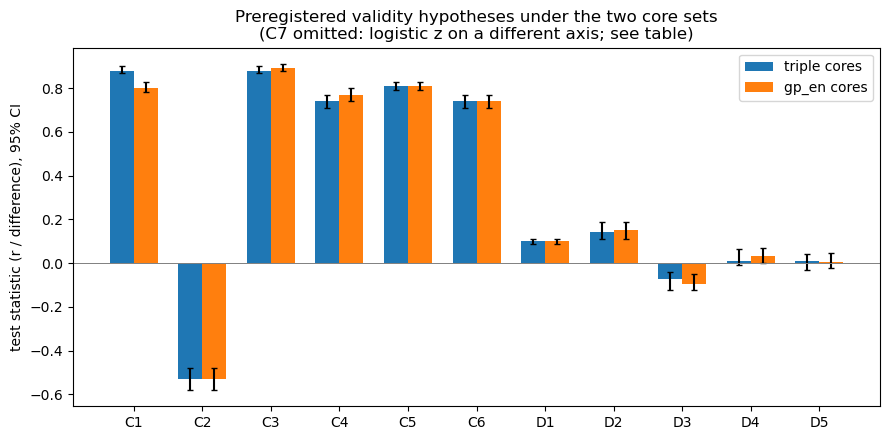

hypotheses with matching support across core sets: 15/16
differing: ['exd4']


In [12]:
allres = pd.concat([res_triple, res_gp_en], ignore_index=True)
wide = allres.pivot_table(index='hypothesis',
                          columns='core_set',
                          values=['statistic', 'p_value', 'supported'],
                          aggfunc='first')
print(wide.to_string())

main = allres[~allres.hypothesis.str.contains('exploratory|exd')]
hyps = [h for h in ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'D1', 'D2', 'D3',
                    'D4', 'D5'] if h in set(main.hypothesis)]
fig, ax = plt.subplots(figsize=(9, 4.5))
w = 0.35
offsets = {'triple': -w / 2, 'gp_en': w / 2}
colors = {'triple': 'tab:blue', 'gp_en': 'tab:orange'}
x = np.arange(len(hyps))
for set_name in ('triple', 'gp_en'):
    sub = main[main.core_set == set_name].set_index('hypothesis')
    vals = sub.loc[hyps, 'statistic'].astype(float)
    los = (vals - sub.loc[hyps, 'ci_lower'].astype(float)).clip(lower=0)
    his = (sub.loc[hyps, 'ci_upper'].astype(float) - vals).clip(lower=0)
    ax.bar(x + offsets[set_name], vals, w, yerr=[los, his], capsize=2,
           color=colors[set_name], label=f'{set_name} cores')
ax.axhline(0, color='gray', lw=0.7)
ax.set_xticks(x)
ax.set_xticklabels(hyps)
ax.set_ylabel('test statistic (r / difference), 95% CI')
ax.set_title('Preregistered validity hypotheses under the two core sets\n'
             '(C7 omitted: logistic z on a different axis; see table)')
ax.legend()
fig.tight_layout()
fig.savefig(fig_dir / 'convdiv_core_comparison.png', dpi=150,
            bbox_inches='tight')
plt.show()
agree = (wide['supported']['triple'] == wide['supported']['gp_en'])
print(f"hypotheses with matching support across core sets: "
      f"{int(agree.sum())}/{len(agree)}")
if not agree.all():
    print('differing:', list(agree.index[~agree]))